In [16]:
import sys
from pathlib import Path

In [17]:
root = Path(".").resolve()
sys.path.append(str(root))

In [18]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [19]:
from src.extract_inputs import get_inputs
from src.option_pricing import bs_price

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
from datetime import date

inputs = get_inputs("2025-04-09")
inputs

{'S0': 504.38,
 'r': 0.044199999999999996,
 'q': 0.013446,
 'trade_date': datetime.date(2025, 4, 9),
 'expiry_date': datetime.date(2025, 5, 9),
 'valuation_date': datetime.date(2025, 5, 2),
 'K_put': 480.0,
 'K_call': 530.0,
 'iv_put_entry': 0.33887500000000004,
 'iv_call_entry': 0.180364,
 'contract_multiplier': 100,
 'contracts_put_sold': 1000,
 'contracts_call_bought': 1000}

In [22]:
S0 = inputs["S0"]
r = inputs["r"]
q = inputs["q"]
trade_date = inputs["trade_date"]
expiry_date = inputs["expiry_date"]
valuation_date = inputs["valuation_date"]

K_put_short = inputs["K_put"]      
K_call = inputs["K_call"]    

iv_put_short_entry = inputs["iv_put_entry"]
iv_call_entry = inputs["iv_call_entry"]

contract_multiplier = inputs["contract_multiplier"]
N_put_short = inputs["contracts_put_sold"]
N_call = inputs["contracts_call_bought"]

In [23]:
def year_fraction(d1, d2):
    return (d2 - d1).days / 365.0

def round_to_nearest_5(x):
    return 5 * round(x / 5.0)

In [24]:
moneyness_long_put = 0.90
vol_bump_long_put = 0.02  

K_put_long = round_to_nearest_5(S0 * moneyness_long_put)
iv_put_long_entry = iv_put_short_entry + vol_bump_long_put

N_put_long = N_put_short 


In [25]:
T_entry = year_fraction(trade_date, expiry_date)
T_val = year_fraction(valuation_date, expiry_date)

In [26]:
put_short_entry_px = bs_price(S0, K_put_short, T_entry, r, q, iv_put_short_entry, "put")
put_long_entry_px  = bs_price(S0, K_put_long,  T_entry, r, q, iv_put_long_entry,  "put")
call_entry_px      = bs_price(S0, K_call,      T_entry, r, q, iv_call_entry,      "call")

entry_cost = (
    -N_put_short * put_short_entry_px
    + N_put_long * put_long_entry_px
    + N_call * call_entry_px
) * contract_multiplier

entry_cost

-238139.3808726075

In [27]:
scenario_names = ["-15%", "-10%", "-5%", "0%", "+5%", "+10%", "+15%"]
spot_multipliers = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]

iv_put_short_val = iv_put_short_entry
iv_put_long_val  = iv_put_long_entry
iv_call_val      = iv_call_entry

rows = []
for name, mult in zip(scenario_names, spot_multipliers):
    S_scn = S0 * mult
    
    put_short_val_px = bs_price(S_scn, K_put_short, T_val, r, q, iv_put_short_val, "put")
    put_long_val_px  = bs_price(S_scn, K_put_long,  T_val, r, q, iv_put_long_val,  "put")
    call_val_px      = bs_price(S_scn, K_call,      T_val, r, q, iv_call_val,      "call")
    
    mtm = (
        -N_put_short * put_short_val_px
        + N_put_long * put_long_val_px
        + N_call * call_val_px
    ) * contract_multiplier
    
    pnl = mtm - entry_cost
    
    rows.append({
        "scenario": name,
        "spot_multiplier": mult,
        "S_val": S_scn,
        "put_short_val": put_short_val_px,
        "put_long_val": put_long_val_px,
        "call_val": call_val_px,
        "mtm": mtm,
        "pnl": pnl,
    })

putspread_scenarios_df = pd.DataFrame(rows)
putspread_scenarios_df

,scenario,spot_multiplier,S_val,put_short_val,put_long_val,call_val,mtm,pnl
0,-15%,0.85,428.723,51.039615,27.270698,0.000000e+00,-2.376892e+06,-2.138752e+06
1,-10%,0.90,453.942,27.055959,9.405127,6.124332e-10,-1.765083e+06,-1.526944e+06
2,-5%,0.95,479.161,9.253574,1.744946,8.461697e-05,-7.508544e+05,-5.127150e+05
3,0%,1.00,504.380,1.685167,0.160368,1.218888e-01,-1.402911e+05,9.784833e+04
4,+5%,1.05,529.599,0.149608,0.007345,5.232098e+00,5.089836e+05,7.471229e+05
5,+10%,1.10,554.818,0.006485,0.000176,2.529174e+01,2.528543e+06,2.766683e+06
6,+15%,1.15,580.037,0.000144,0.000002,5.033699e+01,5.033685e+06,5.271824e+06


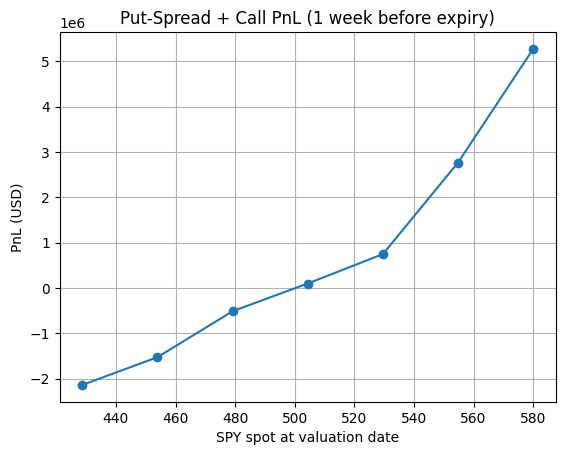

In [28]:
plt.figure()
plt.plot(putspread_scenarios_df["S_val"], putspread_scenarios_df["pnl"], marker="o")
plt.xlabel("SPY spot at valuation date")
plt.ylabel("PnL (USD)")
plt.title("Put-Spread + Call PnL (1 week before expiry)")
plt.grid(True)
plt.show()

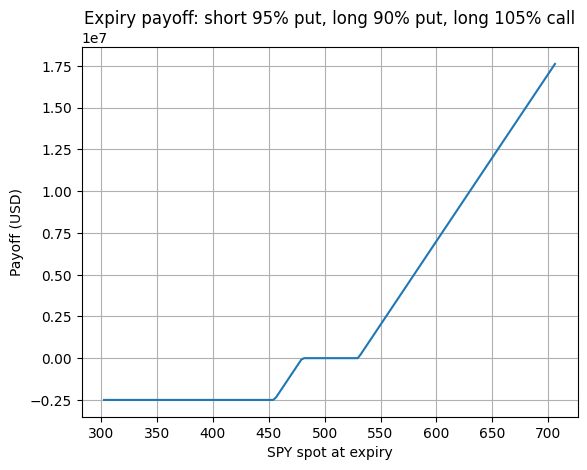

In [29]:
S_grid = np.linspace(0.6 * S0, 1.4 * S0, 161)
payoff_putspread = (
    -N_put_short * np.maximum(K_put_short - S_grid, 0.0)
    + N_put_long * np.maximum(K_put_long  - S_grid, 0.0)
    + N_call      * np.maximum(S_grid     - K_call, 0.0)
) * contract_multiplier

plt.figure()
plt.plot(S_grid, payoff_putspread)
plt.xlabel("SPY spot at expiry")
plt.ylabel("Payoff (USD)")
plt.title("Expiry payoff: short 95% put, long 90% put, long 105% call")
plt.grid(True)
plt.show()

Bonus B

In [14]:
notional = N_call * contract_multiplier * S0  

rows_spy = []
for name, mult in zip(scenario_names, spot_multipliers):
    S_scn = S0 * mult
    pnl_spy = (S_scn - S0) * (notional / S0)
    rows_spy.append({"scenario": name, "S_val": S_scn, "pnl_spy": pnl_spy})

spy_scenarios_df = pd.DataFrame(rows_spy)
spy_scenarios_df


,scenario,S_val,pnl_spy
0,-15%,428.723,-7565700.0
1,-10%,453.942,-5043800.0
2,-5%,479.161,-2521900.0
3,0%,504.380,0.0
4,+5%,529.599,2521900.0
5,+10%,554.818,5043800.0
6,+15%,580.037,7565700.0


In [15]:
comparison_df = putspread_scenarios_df[["scenario", "S_val", "pnl"]].merge(
    spy_scenarios_df[["scenario", "pnl_spy"]],
    on="scenario"
)
comparison_df.rename(columns={"pnl": "pnl_putspread"}, inplace=True)
comparison_df


,scenario,S_val,pnl_putspread,pnl_spy
0,-15%,428.723,-2.138752e+06,-7565700.0
1,-10%,453.942,-1.526944e+06,-5043800.0
2,-5%,479.161,-5.127150e+05,-2521900.0
3,0%,504.380,9.784833e+04,0.0
4,+5%,529.599,7.471229e+05,2521900.0
5,+10%,554.818,2.766683e+06,5043800.0
6,+15%,580.037,5.271824e+06,7565700.0


In [31]:
from src.engine import run_engine_df
rr_results = run_engine_df("2025-04-09")

rr = rr_results["scenarios_df"][["scenario", "S_val", "pnl"]].rename(

    columns={"pnl": "pnl_rr"}
)

ps = putspread_scenarios_df[["scenario", "S_val", "pnl"]].rename(
    columns={"pnl": "pnl_putspread"}
)

spy = spy_scenarios_df[["scenario", "S_val", "pnl_spy"]]

comparison_df = rr.merge(ps, on=["scenario", "S_val"]).merge(spy, on=["scenario", "S_val"])
comparison_df


,scenario,S_val,pnl_rr,pnl_putspread,pnl_spy
0,-15%,428.723,-4.476355e+06,-2.138752e+06,-7565700.0
1,-10%,453.942,-2.077989e+06,-1.526944e+06,-5043800.0
2,-5%,479.161,-2.977423e+05,-5.127150e+05,-2521900.0
3,0%,504.380,4.712788e+05,9.784833e+04,0.0
4,+5%,529.599,1.135856e+06,7.471229e+05,2521900.0
5,+10%,554.818,3.156133e+06,2.766683e+06,5043800.0
6,+15%,580.037,5.661291e+06,5.271824e+06,7565700.0


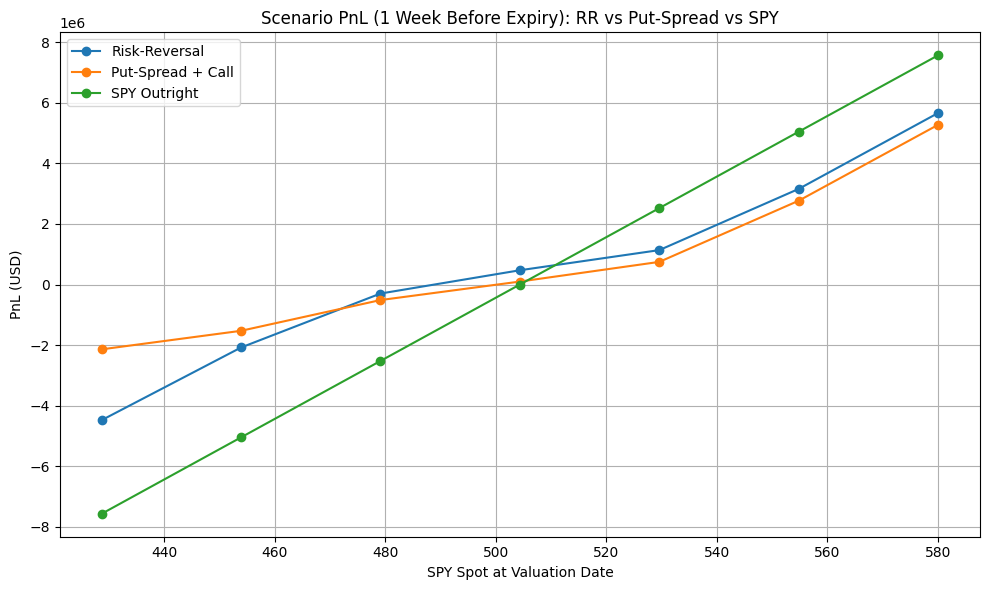

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(comparison_df["S_val"], comparison_df["pnl_rr"],
         marker="o", label="Risk-Reversal")
plt.plot(comparison_df["S_val"], comparison_df["pnl_putspread"],
         marker="o", label="Put-Spread + Call")
plt.plot(comparison_df["S_val"], comparison_df["pnl_spy"],
         marker="o", label="SPY Outright")

plt.title("Scenario PnL (1 Week Before Expiry): RR vs Put-Spread vs SPY")
plt.xlabel("SPY Spot at Valuation Date")
plt.ylabel("PnL (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

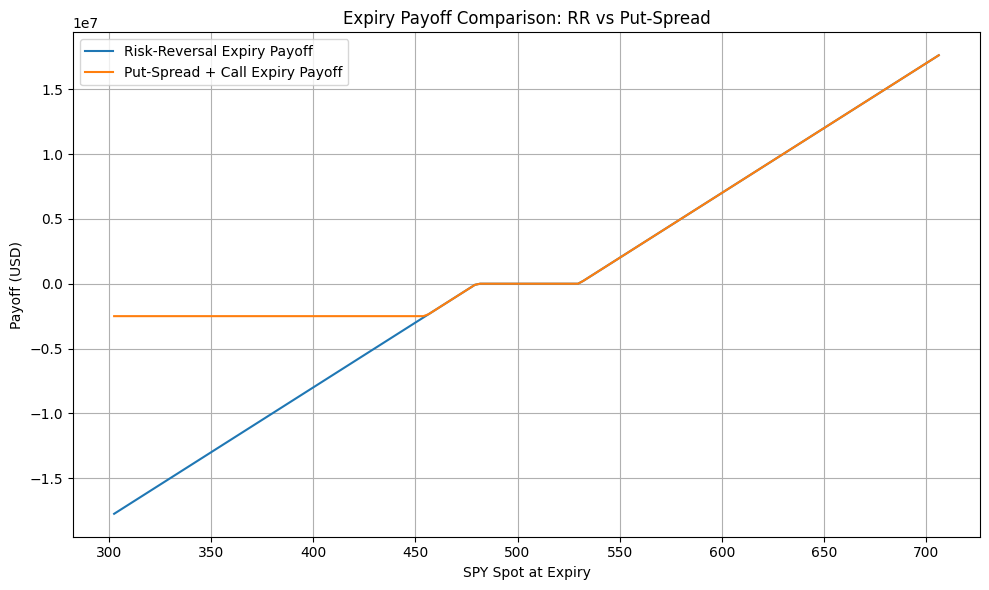

In [33]:
S_grid = rr_results["payoff_df"]["S_expiry"]
rr_payoff = rr_results["payoff_df"]["payoff"]

ps_payoff = payoff_putspread  

plt.figure(figsize=(10, 6))
plt.plot(S_grid, rr_payoff, label="Risk-Reversal Expiry Payoff")
plt.plot(S_grid, ps_payoff, label="Put-Spread + Call Expiry Payoff")
plt.xlabel("SPY Spot at Expiry")
plt.ylabel("Payoff (USD)")
plt.title("Expiry Payoff Comparison: RR vs Put-Spread")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
comparison_df.style.format({
    "pnl_rr": "{:,.0f}",
    "pnl_putspread": "{:,.0f}",
    "pnl_spy": "{:,.0f}"
})

,scenario,S_val,pnl_rr,pnl_putspread,pnl_spy
0,-15%,428.723000,"-4,476,355","-2,138,752","-7,565,700"
1,-10%,453.942000,"-2,077,989","-1,526,944","-5,043,800"
2,-5%,479.161000,"-297,742","-512,715","-2,521,900"
3,0%,504.380000,"471,279","97,848",0
4,+5%,529.599000,"1,135,856","747,123","2,521,900"
5,+10%,554.818000,"3,156,133","2,766,683","5,043,800"
6,+15%,580.037000,"5,661,291","5,271,824","7,565,700"



To reduce the extreme tail risk of the original risk-reversal, we evaluate an alternative structure where the short 95% put is paired with a long 90% put, effectively creating a put-spread alongside the long 105% call. This modification significantly improves downside protection: at a –15% SPY move one week before expiry, the put-spread loses about $2.1M compared to $4.5M for the risk-reversal, while still preserving most of the upside convexity. We also compare both structures to buying SPY outright on equivalent notional. SPY delivers the strongest upside performance in bullish scenarios but suffers the largest losses during drawdowns. In contrast, the put-spread offers the best downside profile, the risk-reversal delivers the strongest theta and skew premium, and SPY provides pure directional exposure. Overall, the put-spread is preferable when skew is rich but risk tolerance is limited, the risk-reversal is attractive when one has strong bullish conviction and can tolerate tail risk, and SPY is preferred when the investor wants straightforward delta exposure without volatility or skew considerations.
